In [1]:
import mkl
mkl.set_num_threads(20)

import numpy as np
import scipy as sp 
import glob
from dyconnmap import tvfcg
from dyconnmap.fc import IPLV, Corr
from dyconnmap.cluster import NeuralGas
from dyconnmap.ts import transition_rate, occupancy_time
from dyconnmap.ts import markov_matrix
from tqdm import tqdm
from scipy.stats import zscore
from joblib import Parallel, delayed
import fathon
from fathon import fathonUtils as fu
from natsort import natsorted


In [2]:

%load_ext autoreload
%autoreload 2
%matplotlib widget
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 8})
plt.rcParams.update({'pdf.fonttype':42})
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [3]:
paths_e = natsorted(glob.glob('/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/10min_beta_sim_hcpmeg_20khz_fftfilterdown500hz/beta_E_activity*.npz'))

dsample_1 = 40
nsim = 10
#dsample again if needed e.g. to 250hz for faster calculations
dsample_2 = 1
#dsample nodes
dsample_nodes = 40

sims = np.concatenate([np.load(p)['arr_0'][:,::dsample_2] for p in paths_e[:nsim]],axis=-1)

fs = 20000//(dsample_1*dsample_2)

eigenvectors = np.load('/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/eigvecs_DTI_fgCCfix_subcortex_dti50.npy')

sims_g = np.dot(eigenvectors,sims)[::dsample_nodes]

del sims


In [12]:
paths_e = natsorted(glob.glob('/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/10min_beta_sim_hcpmeg_20khz_fftfilterdown500hz/beta_I_activity*.npz'))

dsample_1 = 40
nsim = 10
#dsample again if needed e.g. to 250hz for faster calculations
dsample_2 = 1
#dsample nodes
dsample_nodes = 40

sims = np.concatenate([np.load(p)['arr_0'][:,::dsample_2] for p in paths_e[:nsim]],axis=-1)

fs = 20000//(dsample_1*dsample_2)

eigenvectors = np.load('/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/eigvecs_DTI_fgCCfix_subcortex_dti50.npy')

sims_gi = np.dot(eigenvectors,sims)[::dsample_nodes]

del sims


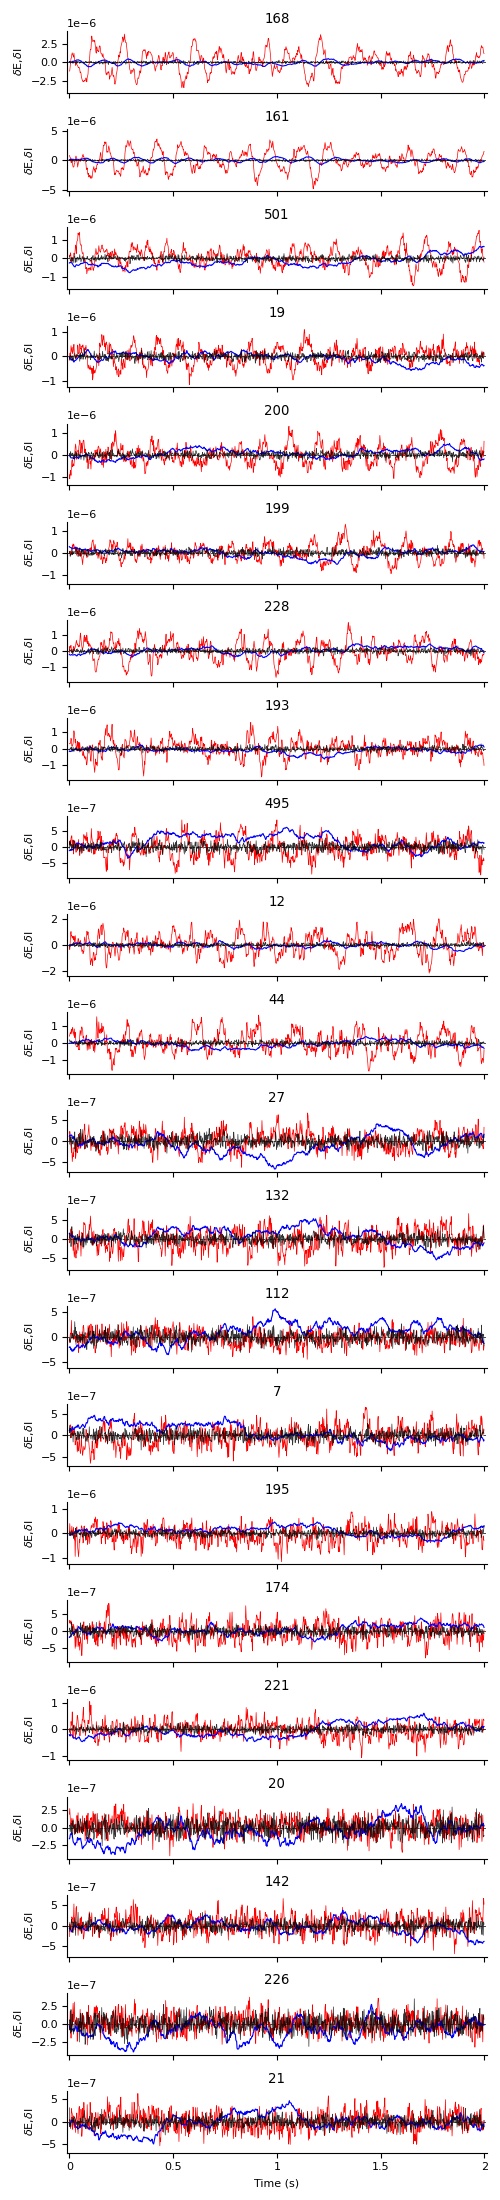

In [15]:
#12,17,19,42,44,57,60,62,302,305,309,314,316,325,479,483,487,476,463,465
plt.close('all')
# nodes = [12,17,19,42,44,57,60,62,302,305,309,314,316,325,479,483,487,476,463,465]
# nodes=np.array(nodes)#+2
nodes = [7,19,12,27,20,21,44,112,142,132,168,161,174,200,199,193,195,228,221,226,495,501]
#nodes = np.arange(500,510)
alpha_power = []
for node in nodes:
    power_e = np.abs(np.fft.rfft(sims_g[node,:], axis=-1))**2
    power_e /= np.sum(power_e)
    power_i = np.abs(np.fft.rfft(sims_g[node,:], axis=-1))**2
    power_i /= np.sum(power_i)
    freqs = np.fft.rfftfreq(sims_g.shape[-1], d=1/500)
    #alpha_power.append(np.sum(power_e[(freqs>6) & (freqs<11)])+np.sum(power_i[(freqs>6) & (freqs<11)]))
    alpha_power.append(np.sum(power_i[(freqs>6) & (freqs<11)]))
    
nodes=np.array(nodes)[np.argsort(alpha_power)[::-1]]


fig,ax = plt.subplots(len(nodes),1, figsize=(5,len(nodes)),sharex=True, tight_layout=True)
for i,numnode in enumerate(nodes):
    
    ax[i].plot(np.arange(-5,1005),np.zeros(1010),c='k',ls='--',lw=0.5)


    ax[i].plot(sims_g[numnode,1000:2000],c='r',lw=0.5)

    ax[i].plot(3*sims_gi[numnode,1000:2000],c='b',lw=0.8)

    ax[i].plot(1e-7*np.random.default_rng().normal(0, 1, size=1000),c='k',alpha=0.8,lw=0.5)

    
    ax[i].set_xlim(-5,1005)
    ax[i].set_ylabel('$\delta$E,$\delta$I')
    ax[i].set_title(numnode)
    
    ylim = np.abs(ax[i].get_ylim()).max() 
    ax[i].set_ylim(-ylim,ylim)
    

ax[-1].set_xticks([0,250,500,750,1000],[0,0.5,1,1.5,2])
ax[-1].set_xlabel('Time (s)')
plt.savefig(f"/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/Figures/new_example_timecourses_hcpmeg_wnoise.pdf", dpi=600, transparent=True) 

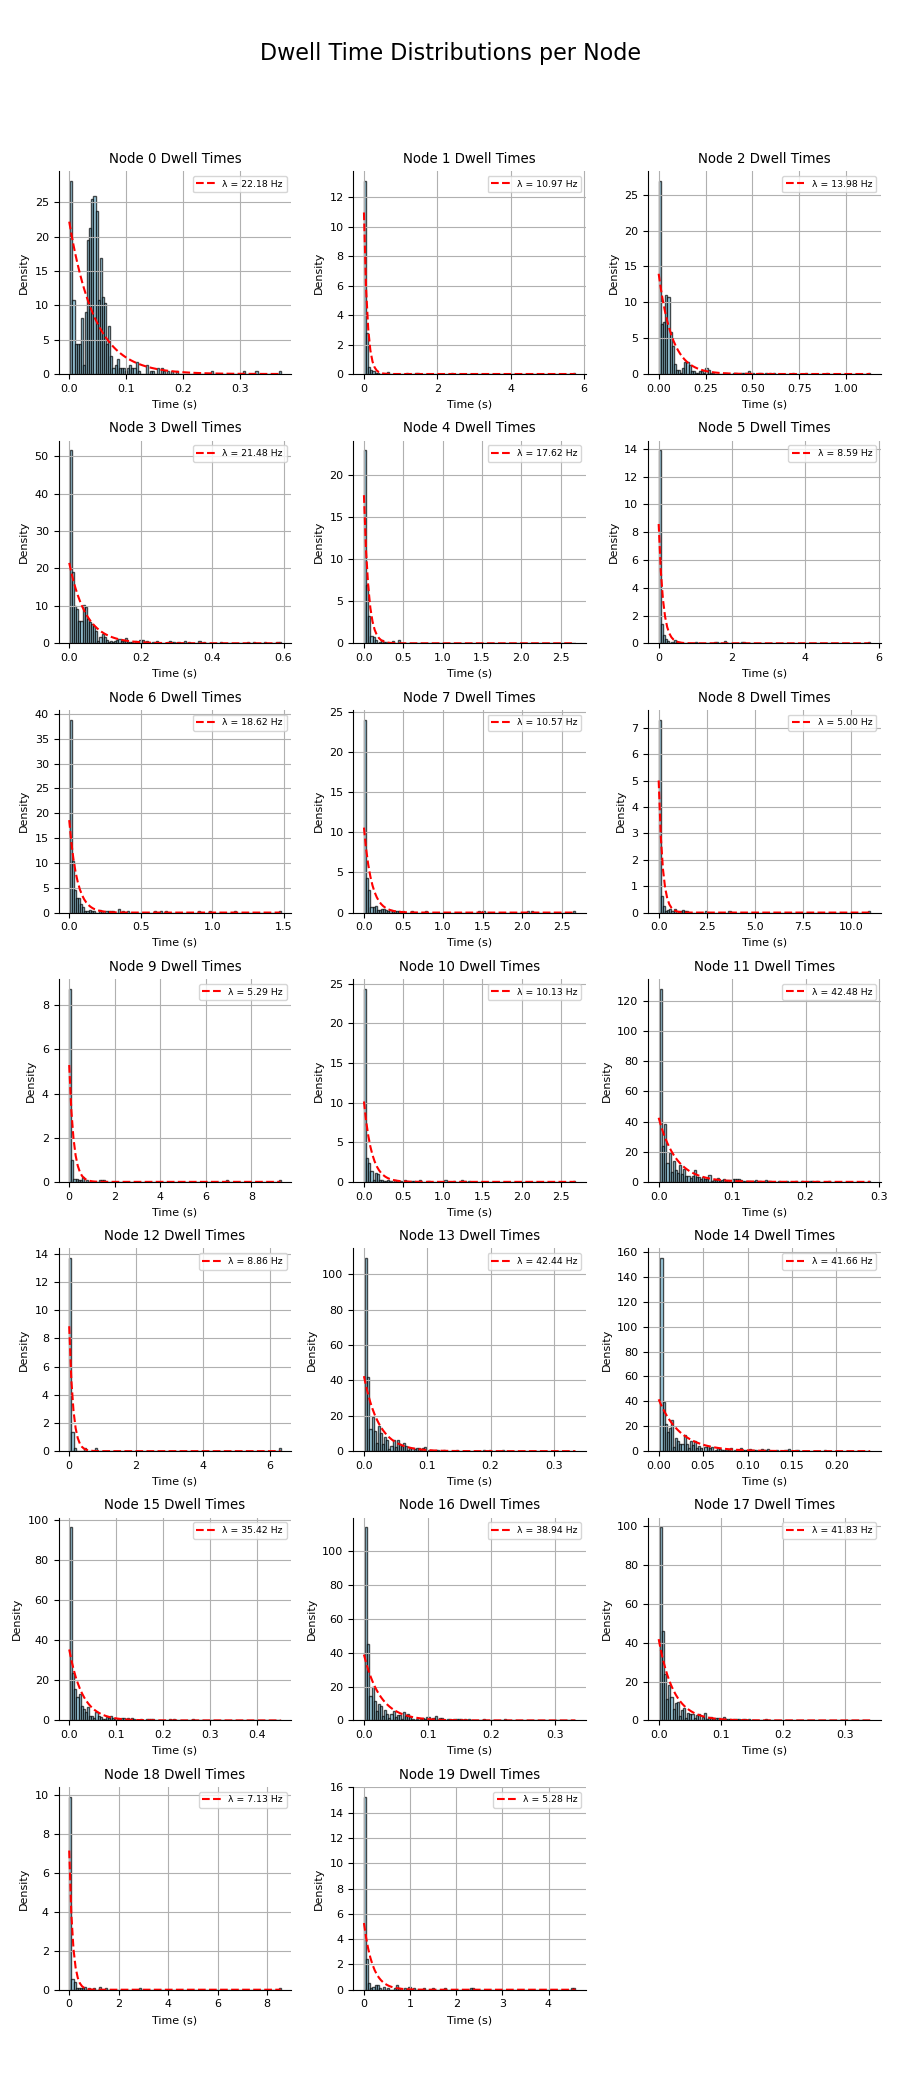

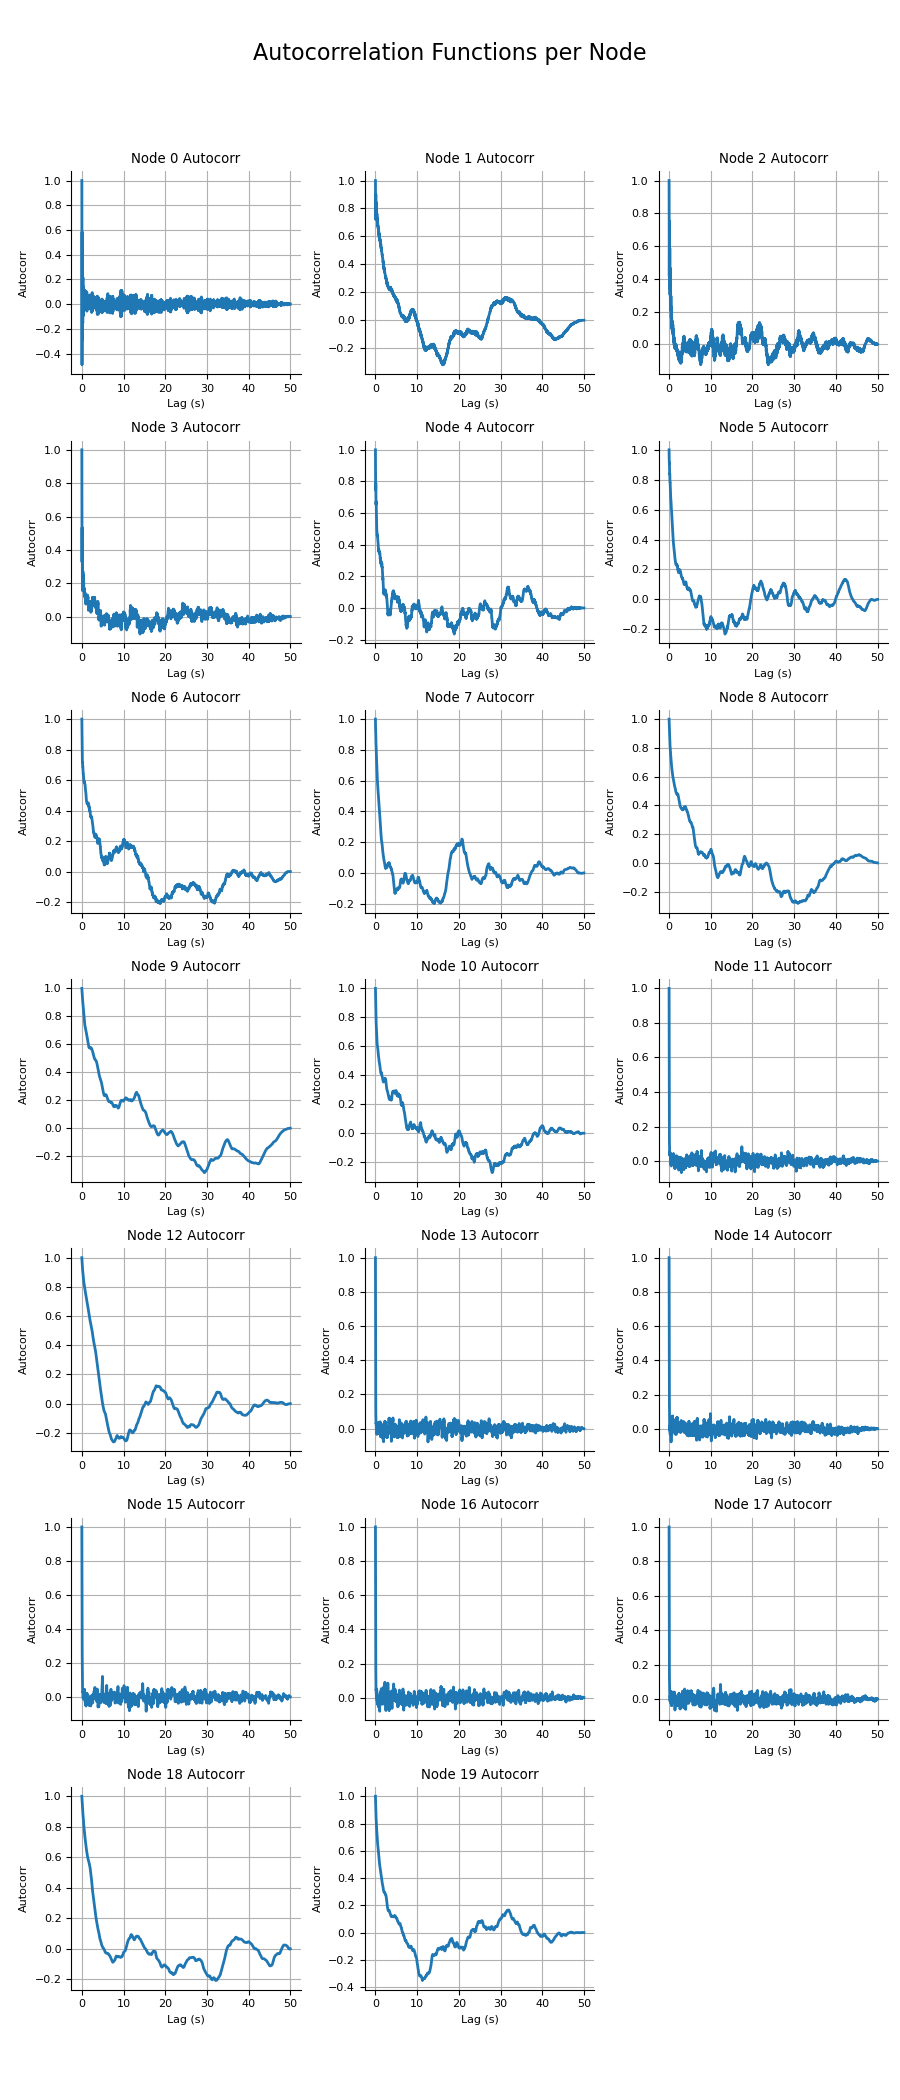

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
from scipy.stats import expon

# === Replace with your actual data ===
# Data shape: (n_nodes, n_timepoints)
data = sims_gi[nodes]

n_nodes, n_timepoints = data.shape
sampling_rate = 500  # Hz (adjust as needed)

# === Define helper functions ===

def compute_dwell_times(time_series, threshold):
    state = time_series > threshold
    state_changes = np.diff(state.astype(int))
    transitions_up = np.where(state_changes == 1)[0]
    transitions_down = np.where(state_changes == -1)[0]

    # Ensure alignment
    if transitions_down.size == 0 or transitions_up.size == 0:
        return np.array([])

    if transitions_down[0] < transitions_up[0]:
        transitions_down = transitions_down[1:]

    min_len = min(len(transitions_up), len(transitions_down))
    if min_len == 0:
        return np.array([])

    transitions_up = transitions_up[:min_len]
    transitions_down = transitions_down[:min_len]

    dwell_times = (transitions_down - transitions_up) / sampling_rate
    return dwell_times

def compute_autocorrelation(time_series):
    signal = (time_series - np.mean(time_series)) / np.std(time_series)
    autocorr = correlate(signal, signal, mode='full')
    autocorr = autocorr[autocorr.size // 2:]  # positive lags
    autocorr /= autocorr[0]  # normalize
    return autocorr

# === Step 1: Dwell Time Distributions for all nodes ===

n_cols = 3
n_rows = int(np.ceil(n_nodes / n_cols))

plt.figure(figsize=(n_cols * 3, n_rows * 3))

for node in range(n_nodes):
    time_series = data[node, :]
    threshold = 0#np.mean(time_series)

    dwell_times = compute_dwell_times(time_series, threshold)

    plt.subplot(n_rows, n_cols, node + 1)
    if dwell_times.size > 0:
        plt.hist(dwell_times, bins=100, density=True, alpha=0.7, color='skyblue', edgecolor='black')

        # Optional: fit exponential
        params = expon.fit(dwell_times, floc=0)
        x_fit = np.linspace(0, dwell_times.max(), 100)
        pdf_fit = expon.pdf(x_fit, *params)
        plt.plot(x_fit, pdf_fit, 'r--', label=f'λ = {1/params[1]:.2f} Hz')
        plt.legend(fontsize='small')
    
    plt.title(f'Node {node} Dwell Times')
    plt.xlabel("Time (s)")
    plt.ylabel("Density")
    #plt.xscale('log')
    #plt.yscale('log')
    plt.grid(True)

plt.suptitle("Dwell Time Distributions per Node", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# === Step 2: Autocorrelation functions for all nodes ===

plt.figure(figsize=(n_cols * 3, n_rows * 3))

for node in range(n_nodes):
    time_series = data[node, :]
    autocorr = compute_autocorrelation(time_series)
    lags = np.arange(len(autocorr)) / sampling_rate

    plt.subplot(n_rows, n_cols, node + 1)
    plt.plot(lags, autocorr, lw=2)
    plt.title(f'Node {node} Autocorr')
    plt.xlabel("Lag (s)")
    plt.ylabel("Autocorr")
    plt.grid(True)

plt.suptitle("Autocorrelation Functions per Node", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
# signal = zscore(conv_sims_e[::5,::250],axis=-1)#sims_e[::20]
# winsize = 24
# step =  1

#signal = sims_e_phase_shuffle[::20]

#signal = zscore(sims_e[::2],axis=-1)

signal = zscore(sims_g,axis=-1)

winsize = fs*20
step =  winsize//2

start = 0
end = start + winsize

FCs = []
while end < signal.shape[1]:
    print(start)
    FCs.append(np.triu(np.corrcoef(signal[:,start:end])).flatten())
    start += step
    end += step
    
# mkl.set_num_threads(1)   
# def this_window_FC(signal):
#     return np.triu(np.corrcoef(signal)).flatten() 
    
# FCs = np.array(Parallel(n_jobs=23,verbose=1,batch_size=10)(delayed(this_window_FC)(sig) \
#                         for sig in [signal[:,start:(start+winsize)] for start in range(0,signal.shape[-1]-winsize,step)]))

In [ ]:
MM = np.corrcoef(np.array(FCs))


In [ ]:
MM.shape

In [ ]:
#pl.close('all')
pl.figure(figsize=(10,10))
#pl.imshow(np.abs(MM),vmax=np.nanquantile(np.abs(MM),0.9),vmin=np.nanquantile(np.abs(MM),0.1),cmap='turbo')
pl.imshow(MM,vmax=np.nanquantile(MM,0.9),vmin=np.nanquantile(MM,0.1),cmap='turbo')

pl.colorbar()

In [6]:
from scipy.fftpack import rfft, irfft

def phaseScrambleTS(ts):
    """Returns a TS: original TS power is preserved; TS phase is shuffled."""
    fs = rfft(ts)
    # rfft returns real and imaginary components in adjacent elements of a real array
    pow_fs = fs[1:-1:2]**2 + fs[2::2]**2
    phase_fs = np.arctan2(fs[2::2], fs[1:-1:2])
    phase_fsr = phase_fs.copy()
    np.random.shuffle(phase_fsr)
    # use broadcasting and ravel to interleave the real and imaginary components. 
    # The first and last elements in the fourier array don't have any phase information, and thus don't change
    fsrp = np.sqrt(pow_fs[:, np.newaxis]) * np.c_[np.cos(phase_fsr), np.sin(phase_fsr)]
    fsrp = np.r_[fs[0], fsrp.ravel(), fs[-1]]
    tsr = irfft(fsrp)
    return tsr

In [31]:
sims_e_phase_shuffle = np.array(Parallel(n_jobs=15,verbose=1,batch_size=100)(delayed(phaseScrambleTS)(sims_e[i]) \
                                                        for i in range(sims_e.shape[0])))

[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
[Parallel(n_jobs=23)]: Done   2 out of   2 | elapsed:   14.2s finished
[Parallel(n_jobs=23)]: Done 546 tasks      | elapsed:   19.5s
[Parallel(n_jobs=23)]: Done 15546 tasks      | elapsed:  1.2min
[Parallel(n_jobs=23)]: Done 20214 tasks      | elapsed:  1.5min
[Parallel(n_jobs=23)]: Done 20484 out of 20484 | elapsed:  1.5min finished


In [200]:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='pca', perplexity=30).fit_transform(MM)


In [228]:
X_embedded_shuf = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(MM_shuf)

In [151]:
X_embedded_phase_shuf = TSNE(n_components=2, learning_rate='auto',
                  init='pca', perplexity=30).fit_transform(MM_phase_shuf)

<IPython.core.display.Javascript object>


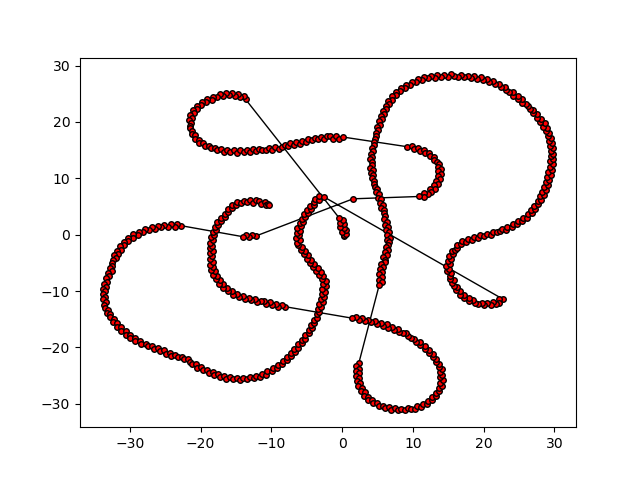

In [201]:
pl.figure()
pl.plot(X_embedded[:,0],X_embedded[:,1],marker='o',mfc='r',c='k',ms=4,lw=1)

<IPython.core.display.Javascript object>


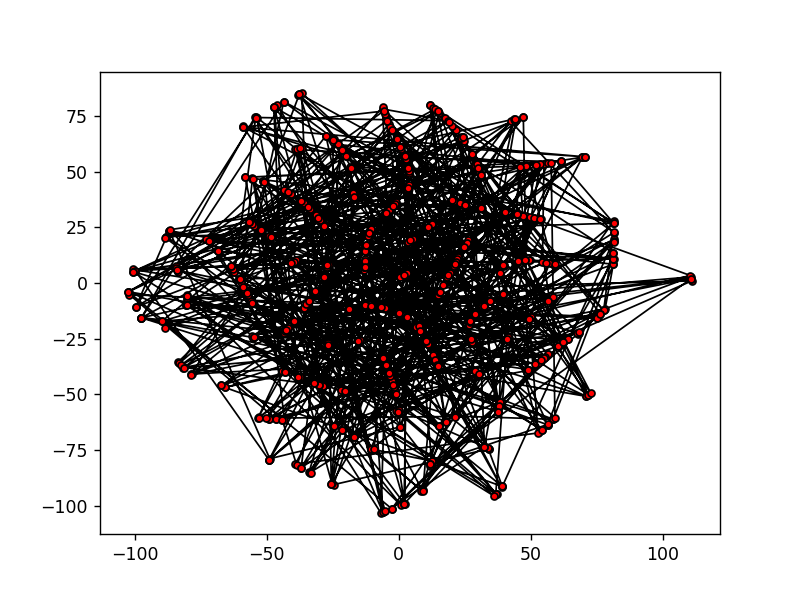

In [245]:
pl.figure()
pl.plot(X_embedded_shuf[:,0],X_embedded_shuf[:,1],marker='o',mfc='r',c='k',ms=4,lw=1)

<IPython.core.display.Javascript object>


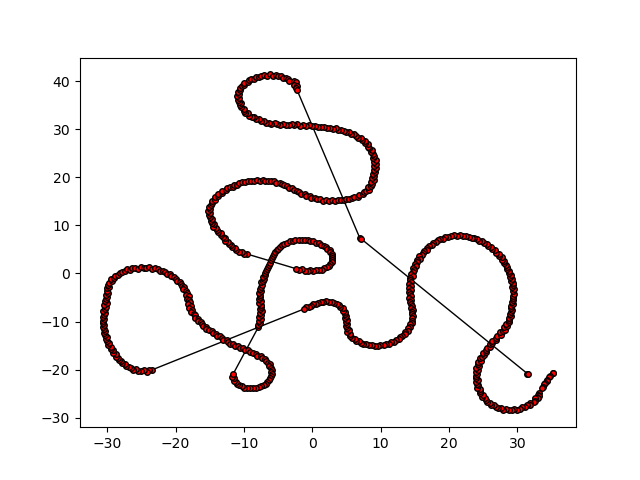

In [152]:
pl.figure()
pl.plot(X_embedded_phase_shuf[:,0],X_embedded_phase_shuf[:,1],marker='o',mfc='r',c='k',ms=4,lw=1)

In [ ]:
pl.figure()
haha = FCs[:,10]
pl.plot(haha)
pl.plot(phaseScrambleTS(haha))

In [176]:
FCs = np.array(FCs)

In [177]:
phase_scrambled_FCs = np.array(Parallel(n_jobs=23,verbose=1,batch_size=10000)(delayed(phaseScrambleTS)\
                                            (FCs[:,i]) for i in range(FCs.shape[1]))).T

[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
[Parallel(n_jobs=23)]: Done   2 out of   2 | elapsed:   18.8s finished
[Parallel(n_jobs=23)]: Done 50046 tasks      | elapsed:   25.3s
[Parallel(n_jobs=23)]: Done 1550046 tasks      | elapsed:  2.2min
[Parallel(n_jobs=23)]: Done 4050046 tasks      | elapsed:  5.2min
[Parallel(n_jobs=23)]: Done 4198401 out of 4198401 | elapsed:  5.3min finished


In [178]:
# pl.figure()
# pl.plot(FCs[:,-20000])
# pl.plot(phase_scrambled_FCs[:,-20000])

In [179]:
MM_phase_shuf = np.corrcoef(phase_scrambled_FCs)


In [180]:
#MM_phase_shuf = MM_phase_shuf[52:,52:]

<IPython.core.display.Javascript object>


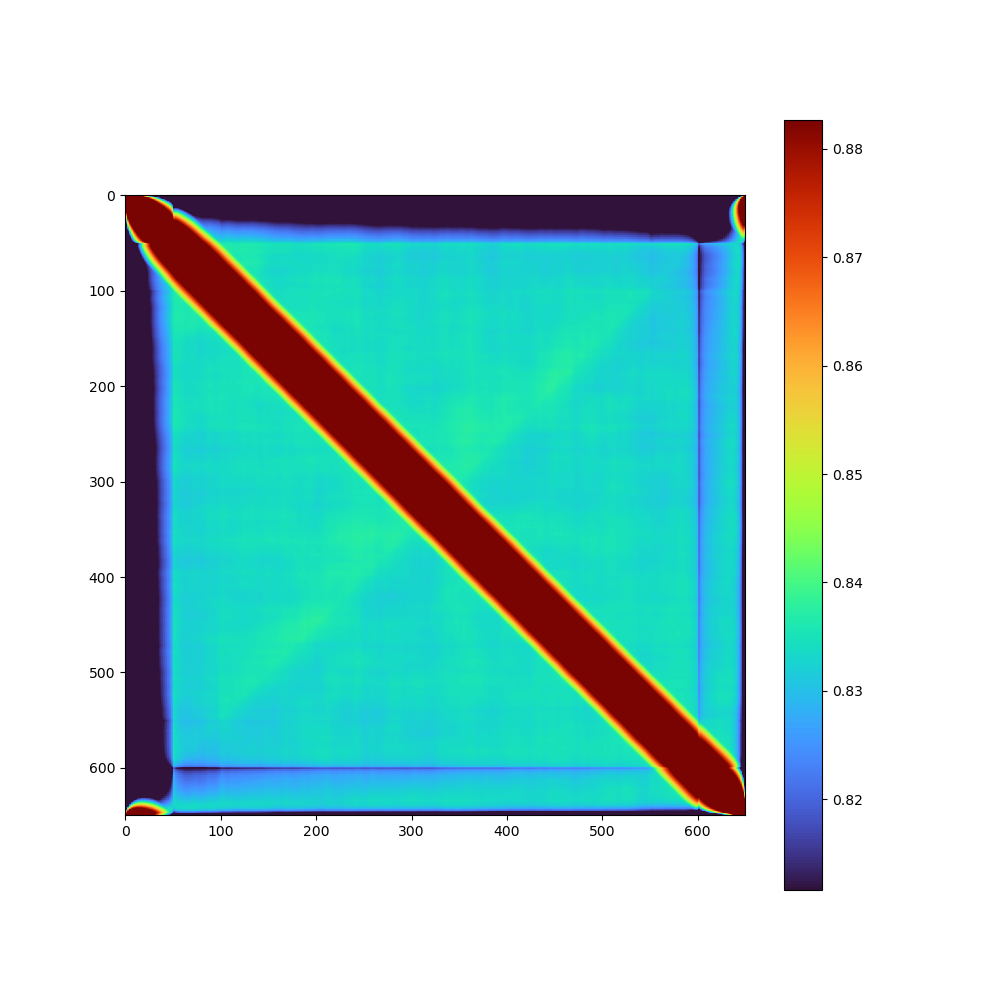

In [181]:
pl.close('all')
pl.figure(figsize=(10,10))
pl.imshow(np.abs(MM_phase_shuf),vmax=np.nanquantile(np.abs(MM_phase_shuf),0.9),vmin=np.nanquantile(np.abs(MM_phase_shuf),0.1),cmap='turbo')
pl.colorbar()

<IPython.core.display.Javascript object>


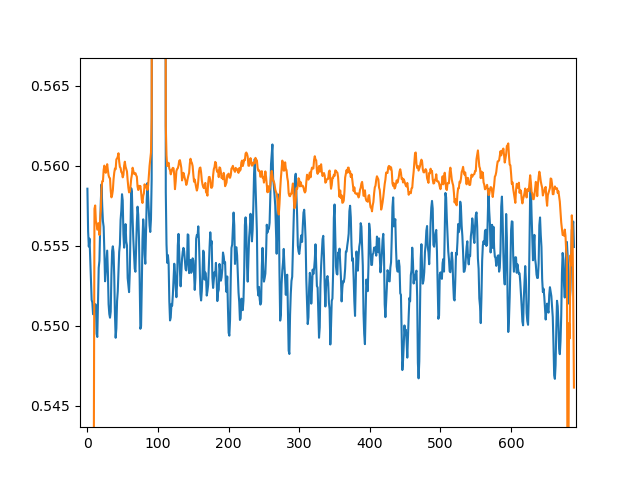

In [153]:
pl.figure()
pl.plot(MM[101])
pl.plot(MM_phase_shuf[101])

In [ ]:
import fathon
from fathon import fathonUtils as fu
H_shuf = []
for num in range(MM_shuf.shape[0]):
    a = fu.toAggregated(np.concatenate((np.abs(MM_shuf)[num,:(num-30)],np.abs(MM_shuf)[num,(num+30):])))

    min_window = 50
    max_window = 250
    fs = 1

    pydfa = fathon.DFA(a)
    winSizes = np.logspace(np.log10(min_window*fs),np.log10(max_window*fs),dtype='int',num=20)#fu.linRangeByStep(2*fs, 20*fs, step=100)
    revSeg = False
    polOrd = 1

    n, F = pydfa.computeFlucVec(winSizes, revSeg=revSeg, polOrd=polOrd)
    H, H_intercept = pydfa.fitFlucVec(logBase=10)
    H_shuf.append(H)

In [182]:
H_orig = []
for num in range(MM.shape[0]):
    a = fu.toAggregated(np.concatenate((np.abs(MM)[num,:(num-30)],np.abs(MM)[num,(num+30):])))

    min_window = 50
    max_window = 300
    fs = 1

    pydfa = fathon.DFA(a)
    winSizes = np.logspace(np.log10(min_window*fs),np.log10(max_window*fs),dtype='int',num=20)#fu.linRangeByStep(2*fs, 20*fs, step=100)
    revSeg = False
    polOrd = 3

    n, F = pydfa.computeFlucVec(winSizes, revSeg=revSeg, polOrd=polOrd)
    H, H_intercept = pydfa.fitFlucVec(logBase=10)
    H_orig.append(H)

In [183]:
H_phase_shuf = []
for num in range(MM_phase_shuf.shape[0]):
    a = fu.toAggregated(np.concatenate((np.abs(MM_phase_shuf)[num,:(num-30)],np.abs(MM_phase_shuf)[num,(num+30):])))

    min_window = 50
    max_window = 300
    fs = 1

    pydfa = fathon.DFA(a)
    winSizes = np.logspace(np.log10(min_window*fs),np.log10(max_window*fs),dtype='int',num=20)#fu.linRangeByStep(2*fs, 20*fs, step=100)
    revSeg = False
    polOrd = 3

    n, F = pydfa.computeFlucVec(winSizes, revSeg=revSeg, polOrd=polOrd)
    H, H_intercept = pydfa.fitFlucVec(logBase=10)
    H_phase_shuf.append(H)

<IPython.core.display.Javascript object>


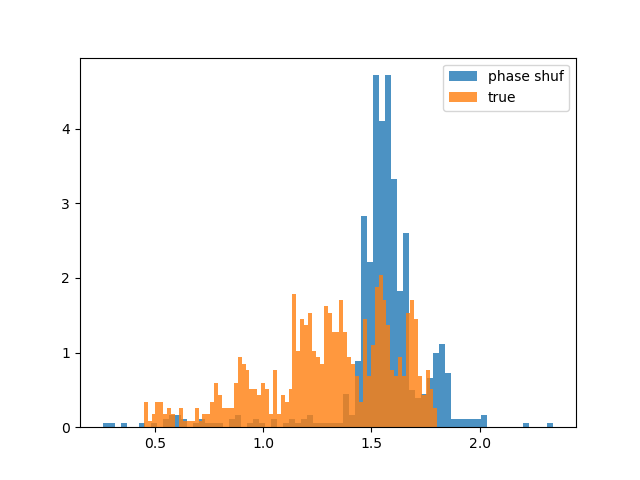

In [184]:
pl.figure()
#pl.hist(H_shuf,bins=25,alpha=0.8)
pl.hist(H_phase_shuf,density=True,bins=75,alpha=0.8,label='phase shuf')
pl.hist(H_orig,density=True,bins=75,alpha=0.8,label='true')
pl.legend()

<IPython.core.display.Javascript object>


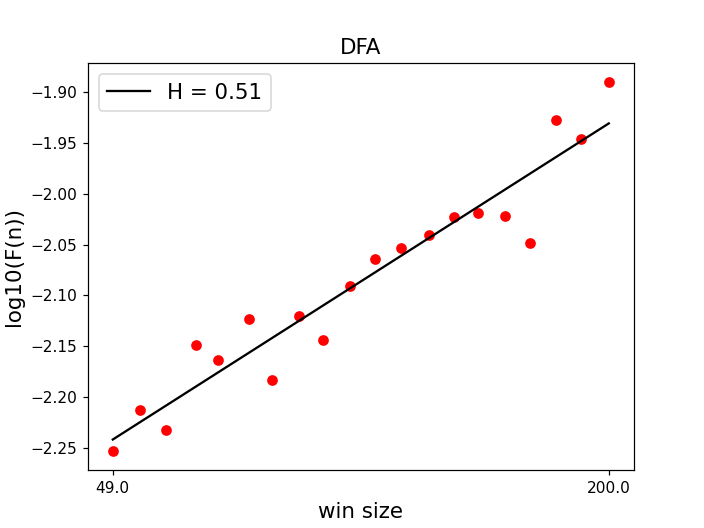

([<matplotlib.axis.XTick at 0x7f33fa0d8a90>,
 [Text(1.6901960800285136, 0, '49.0'), Text(2.3010299956639813, 0, '200.0')])

In [167]:
pl.figure()
pl.plot(np.log10(n), np.log10(F), 'ro')
pl.plot(np.log10(n), H_intercept+H*np.log10(n), 'k-', label='H = {:.2f}'.format(H))
pl.xlabel('win size', fontsize=14)
pl.ylabel('log10(F(n))', fontsize=14)
pl.title(f'DFA', fontsize=14)
pl.legend(loc=0, fontsize=14)
pl.xticks(np.log10([n[0],n[-1]]),[f"{el:.1f}" for el in np.array([n[0],n[-1]])/fs])

In [194]:
MM_shuf = np.corrcoef(np.array(FCs)[np.random.randint(0,len(FCs),len(FCs))])

<IPython.core.display.Javascript object>


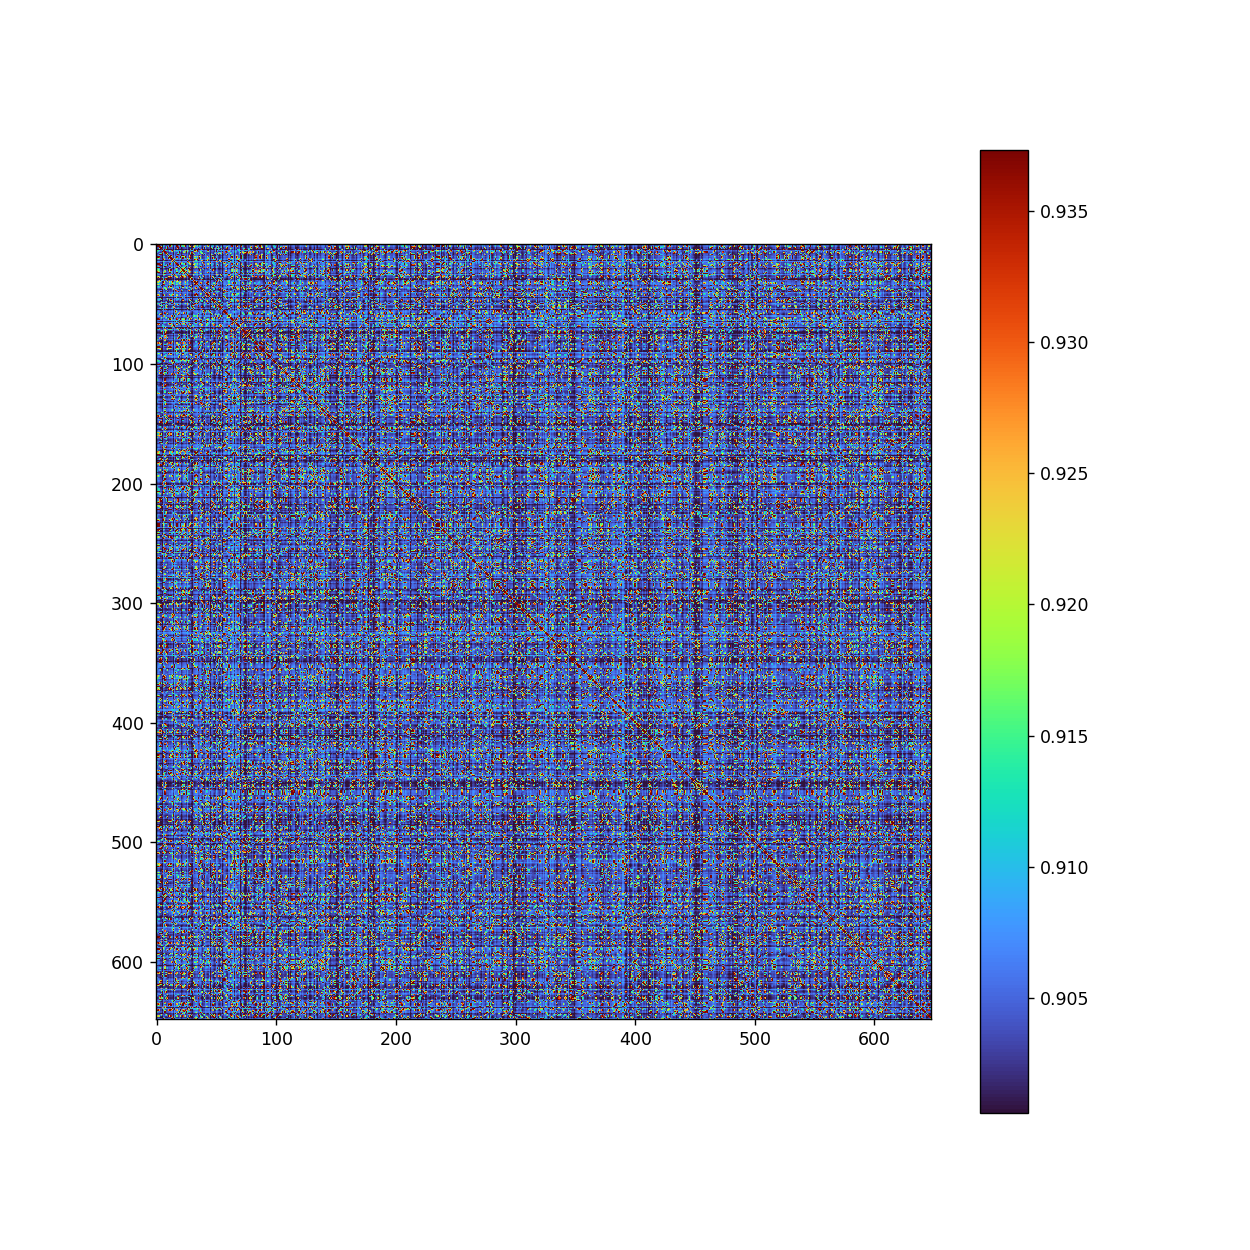

In [195]:
pl.close('all')
pl.figure(figsize=(10,10))
pl.imshow(np.abs(MM_shuf),vmax=np.nanquantile(np.abs(MM_shuf),0.9),vmin=np.nanquantile(np.abs(MM_shuf),0.1),cmap='turbo')
pl.colorbar()

In [263]:
FC = np.corrcoef(sims_e_phase_shuffle)

<IPython.core.display.Javascript object>


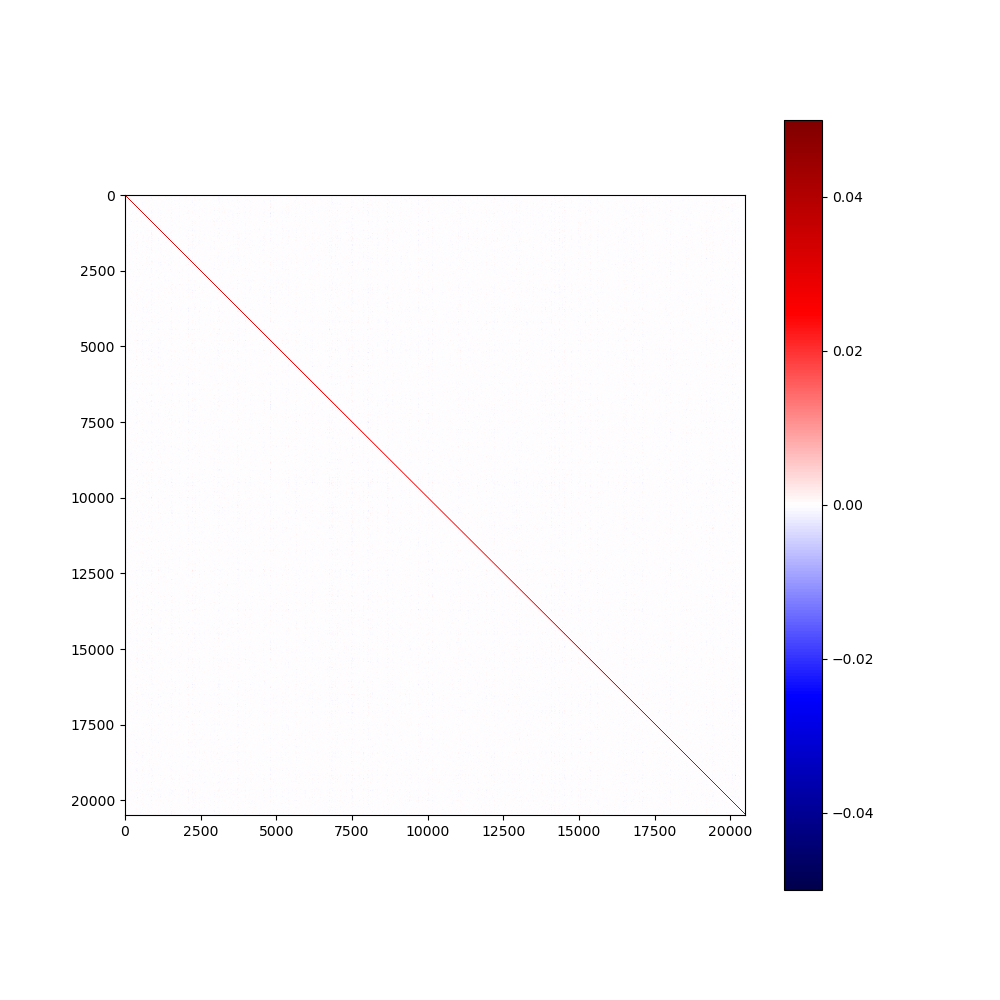

In [264]:
pl.close('all')
pl.figure(figsize=(10,10))
#plt.ylim(3700,1200)
#plt.xlim(5500,7500)
#plt.ylim(10000,9000)
#plt.xlim(11000,12000)
pl.imshow(FC, vmin=-0.05,vmax=0.05,cmap='seismic')
pl.colorbar()

In [7]:
num_channels, num_samples = np.shape(sims_g)
print(f"""
  trials: {num_trials}
channels: {num_channels}
 samples: {num_samples}
""")


  trials: 1
channels: 20484
 samples: 175000



In [8]:
fb = [8.0, 12.0]
cc = 10.0
fs = 250.0
step = 50

In [9]:
estimator = IPLV(fb, fs)
#estimator = Corr(fb, fs)


In [10]:

fcgs = tvfcg(sims_g[::10,:20000], estimator, fb, fs, cc, step)

fcgs_current = np.array(np.real(fcgs))



100%|████████████████████████████████████████████████████████████████████████████████████████████| 394/394 [1:50:47<00:00, 16.87s/it]
[Parallel(n_jobs=23)]: Done 826681344 out of 826681344 | elapsed: 112.2min finished
100%|█████████████████████████████████████████████████████████████████████████████| 826681344/826681344 [08:42<00:00, 1581519.47it/s]


In [11]:
fcgs = fcgs_current
num_fcgs, num_channels, num_channels = np.shape(fcgs)

triu_ind = np.triu_indices_from(np.squeeze(fcgs[0, ...]), k=1)

fcgs = fcgs[:, triu_ind[0], triu_ind[1]]

In [12]:
rng = np.random.RandomState(0)

mdl = NeuralGas(n_protos=12, rng=rng).fit(fcgs)
encoding, symbols = mdl.encode(fcgs)

/home/aqil/.conda/envs/py310/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


In [13]:
h_grp_dist_eo = np.histogram(symbols, bins=mdl.n_protos)


<IPython.core.display.Javascript object>


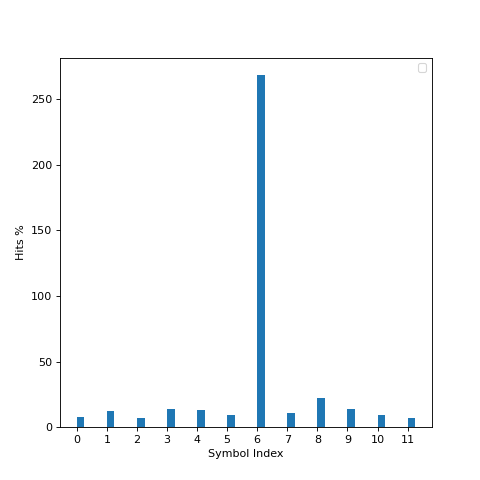

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


([<matplotlib.axis.XTick at 0x7fdc627ce650>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11')])

In [14]:
pl.figure(figsize=(6, 6))

ind = np.arange(mdl.n_protos)
pl.bar(ind + 0.125, h_grp_dist_eo[0], 0.25)

pl.legend()
pl.xlabel('Symbol Index')
pl.ylabel('Hits %')
pl.xticks(np.arange(mdl.n_protos))


<IPython.core.display.Javascript object>


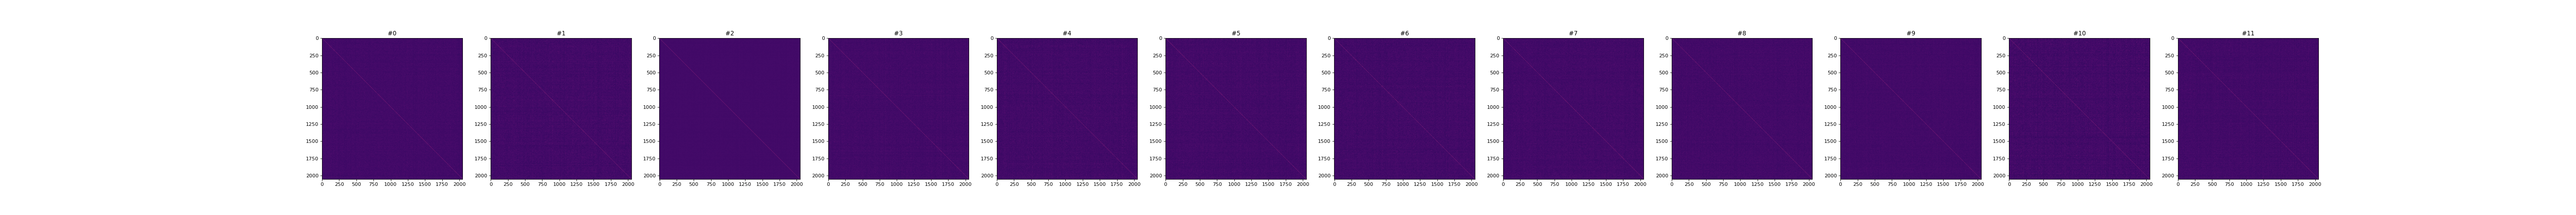

In [19]:
protos_mtx = np.zeros((mdl.n_protos, fcgs_current.shape[1], fcgs_current.shape[2]))

for i in range(mdl.n_protos):
    symbol_state = np.zeros((fcgs_current.shape[1], fcgs_current.shape[2]))
    symbol_state[triu_ind] = mdl.protos[i, :]
    symbol_state = symbol_state + symbol_state.T
    np.fill_diagonal(symbol_state, 1.0)
    
    protos_mtx[i, :, :] = symbol_state

mtx_min = np.min(protos_mtx)
mtx_max = np.max(protos_mtx)

f, ax = pl.subplots(ncols=mdl.n_protos, figsize=(mdl.n_protos*6, 6))
for i in range(mdl.n_protos):
    cax = ax[i].imshow(np.squeeze(protos_mtx[i,...]), vmin=mtx_min, vmax=mtx_max, cmap=pl.cm.inferno)
    ax[i].set_title('#{0}'.format(i))

# move the colorbar to the side ;)
# f.subplots_adjust(right=0.8)
# cbar_ax = f.add_axes([0.82, 0.445, 0.0125, 0.115])
# cb = f.colorbar(cax, cax=cbar_ax)
#ax[-1].colorbar()
#cb.set_label('Imaginary PLV')

<IPython.core.display.Javascript object>


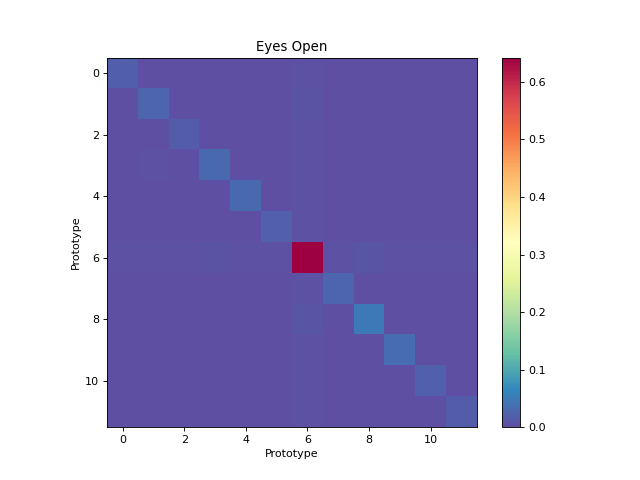

In [16]:
markov_matrix_eo = markov_matrix(symbols)

pl.figure(figsize=(8, 6))
pl.imshow(markov_matrix_eo, cmap=pl.cm.Spectral_r)
pl.xlabel('Prototype')
pl.ylabel('Prototype')
pl.title('Eyes Open')
pl.colorbar()

In [17]:
tr_eo = transition_rate(symbols)
print(f"""
Transition rate
===============
  Eyes open: {tr_eo:.3f}
""")



Transition rate
  Eyes open: 0.074



In [18]:
occ_eo = occupancy_time(symbols)[0]

print(f"""
Occupancy time
==============\n
{occ_eo}
""")
occ_eo.sum()


Occupancy time

[0.0177665  0.02538071 0.01522843 0.03045685 0.03045685 0.02030457
 0.64213198 0.02538071 0.04822335 0.03299492 0.02030457 0.01522843]



0.9238578677177429